In [20]:
import sys
from pathlib import Path


BASE_DIR = Path.cwd()

# go UP until we find 'src'
while BASE_DIR != BASE_DIR.parent:
    if (BASE_DIR / "src").exists():
        break
    BASE_DIR = BASE_DIR.parent

sys.path.insert(0, str(BASE_DIR / "src"))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from models.isolation_forest import IsolationForest
from models.dbscan import DBSCAN
from datetime import date 
from dateutil.relativedelta import relativedelta




import warnings

warnings.filterwarnings('ignore')


In [21]:
#input parameters
data_type = "interday"
stock_name = "CHCL"


features=['rate', 'volume', 'return', 'volatility']

n_estimators=200
contamination=0.01


In [22]:
#Data type

if data_type == "intraday":
    date="2026-04-10"
    data_source = stock_name+".csv";
    df = pd.read_csv(f"data/interday/{date}/{data_source}");

    start_date = "2025-07-09"
    end_date = "2026-04-10"


else : 
    
    # train_start_date = "2020-01-01"
    # train_end_date = "2025-01-01"

    # test_start_date = "2025-01-01"
    # test_end_date = "2026-04-08"


    start_date = date.today()-relativedelta(years=3)
    end_date = date.today()


    print(start_date)
    print(end_date)


    data_source = stock_name+".csv";


    df = pd.read_csv(f"{BASE_DIR}/data/interday/{data_source}");
    df.rename(columns={"close":"rate"},inplace=True)

    


df.head()












2023-05-03
2026-05-03


,transaction_time,open,high,low,rate,per_change,volume,amount,status
0,2006-06-13,800.0,281.0,276.0,281.0,NaN,260950.0,0.0,0
1,2006-06-14,281.0,336.0,295.0,336.0,19.57,99810.0,0.0,0
2,2006-06-15,336.0,352.0,352.0,352.0,4.76,1540.0,0.0,0
3,2006-06-18,352.0,369.0,369.0,369.0,4.83,300.0,0.0,0
4,2006-06-20,369.0,387.0,387.0,387.0,4.88,3640.0,0.0,0


In [23]:
#Data preprocessing
# print(df.columns)


df['Date'] = pd.to_datetime(df['transaction_time'])

df = df.sort_values('Date');
df = df.set_index('Date');
df = df.loc[start_date:end_date].copy()

#drop unnecessary columns
df = df.drop(columns=['transaction_time','status','per_change'])



#Filter dataframe
df = df.drop_duplicates()

# Compute return
df['return'] = df['rate'].pct_change()
df['rate'] = df['rate'].replace(0, np.nan)
df['volatility'] = df['return'].rolling(window=20).std()


print(df[['rate','volume','return','volatility']].isna().sum())

df.head()

rate           0
volume         0
return         1
volatility    20
dtype: int64


,open,high,low,rate,volume,amount,return,volatility
Date,,,,,,,,
2023-05-03,465.0,470.0,460.2,470.0,11516.0,5342577.8,NaN,NaN
2023-05-04,470.0,471.0,458.1,469.0,23898.0,11043804.0,-0.002128,NaN
2023-05-07,460.1,466.0,460.0,464.0,7879.0,3633610.5,-0.010661,NaN
2023-05-08,465.0,466.6,459.0,461.0,5671.0,2608530.3,-0.006466,NaN
2023-05-09,468.9,468.9,457.0,464.0,14581.0,6720768.6,0.006508,NaN


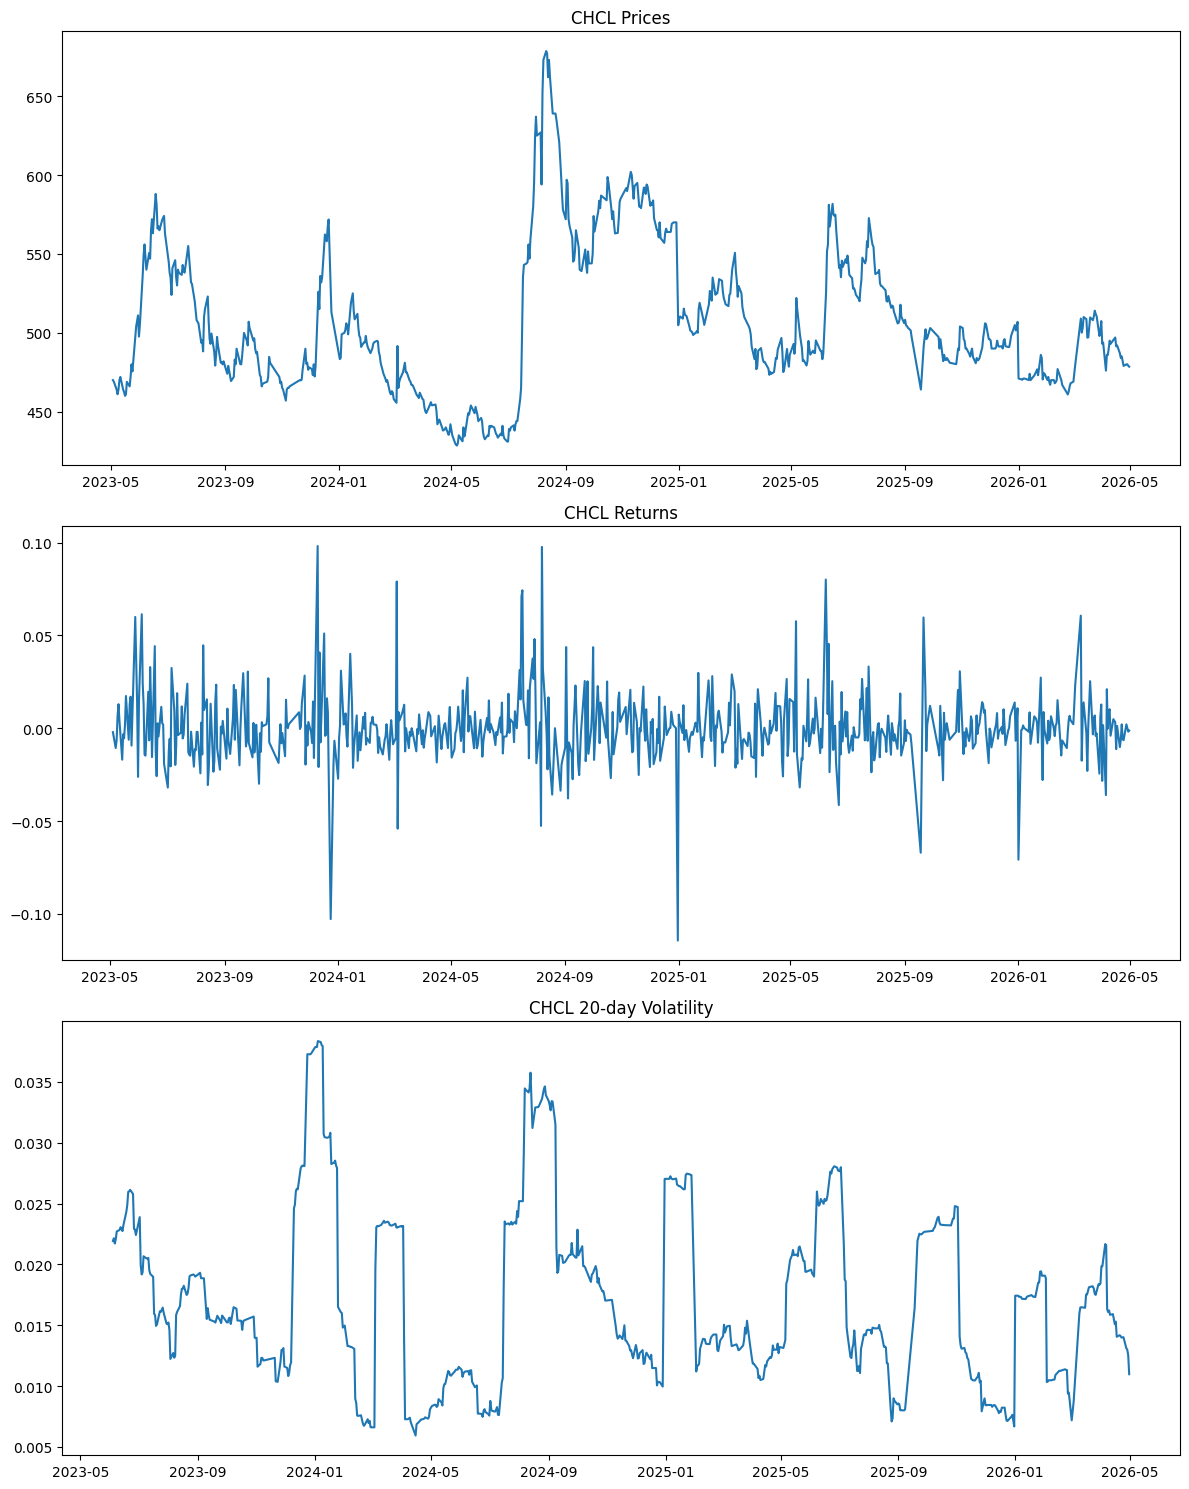

In [24]:
# Plot volatitlity and percent change

fig,axes=plt.subplots(3,1,figsize=(12,15))
axes[0].plot(df.index, df['rate'])
axes[0].set_title(f"{stock_name} Prices")
axes[1].plot(df.index, df['return'])
axes[1].set_title(f"{stock_name} Returns")
axes[2].plot(df.index, df['volatility'])
axes[2].set_title(f"{stock_name} 20-day Volatility")
plt.tight_layout()

plt.show()


In [25]:
#Feature Selection

df[features] = df[features].apply(pd.to_numeric, errors='coerce') #converts every value in features columns to numeric value
df.replace([np.inf, -np.inf], np.nan, inplace=True) #replace inf and -inf with NaN inplace means in the original dataframe
df = df.dropna(subset=features) #drops rows where any of the features are NaN



In [26]:
#Feature Enginneering


#1. Calculate Simple moving averages of last N days

df['SMA_10']=df['rate'].rolling(window=10).mean()
df['SMA_20']=df['rate'].rolling(window=20).mean()
df['SMA_50']=df['rate'].rolling(window=50).mean()



#2. Calculate Relative Strength Index
def calculate_rsi(data,periods=14):
    delta=data.diff()
    gain=(delta.where(delta>0,0)).rolling(window=periods).mean()
    loss=(-delta.where(delta<0,0)).rolling(window=periods).mean()
    rs=gain/loss
    return 100-(100/(1+rs))

df['RSI']=calculate_rsi(df['rate'])


# Above 70 → asset may be overbought (price went up too fast, may pull back)
# Below 30 → asset may be oversold (price dropped too fast, may bounce back)
# Around 50 → neutral momentum


#3. Calculate Boilinger bands
df['Upper_BB']=df['SMA_20']+(df['rate'].rolling(window=20).std()*2)
df['Lower_BB']=df['SMA_20']-(df['rate'].rolling(window=20).std()*2)

df.tail()

,open,high,low,rate,volume,amount,return,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB
Date,,,,,,,,,,,,,,
2026-04-24,486.9,486.9,475.0,479.0,14082.0,6741710.9,-0.006430,0.014019,488.59,490.600,487.328,53.232759,505.847709,475.352291
2026-04-27,479.0,483.0,476.1,480.0,33315.0,15974572.2,0.002088,0.013114,487.29,489.700,487.548,41.978610,505.230886,474.169114
2026-04-28,480.0,484.0,478.0,480.0,27724.0,13304323.7,0.000000,0.012995,485.75,488.650,487.808,42.091153,503.799014,473.500986
2026-04-29,480.0,483.0,475.0,479.1,21272.0,10164462.5,-0.001875,0.012519,483.96,487.235,487.990,34.017595,500.128781,474.341219
2026-04-30,477.0,484.9,473.0,478.5,38316.0,18257463.7,-0.001252,0.010975,482.67,486.510,488.160,22.222222,499.666851,473.353149


In [27]:
#Plot technical analysis
import plotly.graph_objects as go


# Create the figure
fig = go.Figure()

# Add 'Close' price line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['rate'],
    mode='lines',
    name='Close',
    line=dict(color='blue', width=2)
))

# Add 'SMA 10' line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['SMA_10'],
    mode='lines',
    name='SMA 10',
    line=dict(color='green', width=2, dash='dot')
))

# Add 'SMA 50' line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['SMA_50'],
    mode='lines',
    name='SMA 50',
    line=dict(color='orange', width=2, dash='dash')
))

# Add 'Upper BB' line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Upper_BB'],
    mode='lines',
    name='Upper BB',
    line=dict(color='red', width=1, dash='dot')
))

# Add 'Lower BB' line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['Lower_BB'],
    mode='lines',
    name='Lower BB',
    line=dict(color='purple', width=1, dash='dot')
))

# Update layout for a larger figure size and title
fig.update_layout(
    title=f'{stock_name} Stock Price with Technical Indicators',
    xaxis_title='Date',
    yaxis_title='Stock Price',
    legend=dict(x=0, y=1, bgcolor='rgba(255,255,255,0)', bordercolor='rgba(255,255,255,0)'),
    autosize=False,
    width=1200,
    height=600,
   
)

# Show the plot
fig.show()


# Anomaly Detection Techniques

## Z Score Model

In [28]:
from scipy.stats import zscore
import plotly.graph_objects as go


#Calculate Z Score for close prices
df['Anomaly_Z_Score'] = zscore(df['rate'])

# Identify anomalies where Z-Score >3 or < -3
anomalies_zscore = df[abs(df['Anomaly_Z_Score']) > 3]

# Create the figure
fig = go.Figure()

# Add 'Close' price line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['rate'],
    mode='lines',
    name='Close Price',
    line=dict(color='blue', width=2)
))

# Add anomalies (Z-score > 3 or < -3) as red markers
fig.add_trace(go.Scatter(
    x=anomalies_zscore.index,
    y=anomalies_zscore['rate'],
    mode='markers',
    name='Anomalies (Z-Score)',
    marker=dict(color='red', size=8, symbol='circle'),
    showlegend=True
))

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock Price with Anomalies Detected Using Z-Score",
    xaxis_title='Date',
    yaxis_title='Stock Price',
    autosize=False,
    width=1200,
    height=600,
    
)

# Show the plot
fig.show()
# df.sort_values(by="Anomaly_Z_Score",ascending=False).head()
anomalies_zscore.head()


,open,high,low,rate,volume,amount,return,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score
Date,,,,,,,,,,,,,,,
2024-08-07,582.2,653.0,582.2,652.0,556516.0,350013558.5,0.097643,0.034466,604.04,553.610,484.546,76.000000,684.183583,423.036417,3.132924
2024-08-08,665.0,697.0,660.0,673.0,441334.0,297834045.5,0.032209,0.034360,616.64,565.060,488.946,77.310924,695.324919,434.795081,3.589998
2024-08-11,673.0,685.0,667.0,678.6,418051.0,282489073.2,0.008321,0.034135,628.60,576.790,493.556,77.741138,703.353034,450.226966,3.711885
2024-08-12,678.6,690.0,668.4,677.0,501315.0,340543033.1,-0.002358,0.034479,638.30,587.745,498.216,77.147554,708.787341,466.702659,3.677060
2024-08-13,685.0,686.0,660.1,662.0,311116.0,208014291.2,-0.022157,0.035759,644.96,597.595,502.536,71.440129,708.191897,486.998103,3.350578


## Isolation Forest Approach

Anomalies are easier to isolate than normal points and
because anomalies are rare and far from the cluster, a random split can isolate them quickly.
Normal points are surrounded by many neighbors, so they require more splits

It takes 3 parameters:

**1. n_estimators:** 200 means 200 independent trees are built and then sees how quickly a given point gets isolated across these trees.  
**2. contamination:** 0.01 assumes that 1% of the data is anomalous  
**3. max_depth:** cap a trees height   
**4. random_state:** for reproducibility purposes as without it every run gives slightly different anomalies  

Random seed → generate random splits  
         ↓  
Build 200 isolation trees  
         ↓  
Compute anomaly scores  
         ↓  
Use contamination (1%) to label anomalies  

isolation forest converts the average path length to scores  
short path → high anomaly score  
long path → low anomaly score  

max-depth = ceil(log2(max_samples))  
len(X) is how many training rows you have.  
np.log2(n) is “how many times can you halve n before you get down to ~1” — a standard rough size for depth in random/binary tree pictures.  
np.ceil(...) rounds up so you always get an integer depth.  
int(...) makes it a plain Python int for your IsolationForest.  

if training data becomes huge we instead find depth by choosing a max-sample size to randomly select samples to cap a tree's height

### Standardization
To standardize means to convert the data to have a mean of 0 and a standard deviation of 1 such that the data is normalized and the model can learn better
#this is important because the model is sensitive to the scale of the data as return maybe in the range of -0.2 to 0.2 but the other features are in the range of 1000 to 1000000 like quantity


In [29]:
#We can also train the model and fit it in test data, But for simplicity purposes we will fit the model on the entire dataset.

# split_idx = int(len(df) * 0.8) #splits the dataframe into 80% train and 20% test
# df_train = df.iloc[:split_idx].copy() #creates a copy of the train dataframe from the first 80% of the dataframe
# df_test = df.iloc[split_idx:].copy() #creates a copy of the test dataframe from the last 20% of the dataframe


#Only take the selected features
X = df[features];


scaler = StandardScaler() 
X = scaler.fit_transform(X) 

model_if=IsolationForest(n_trees = n_estimators, contamination = contamination, random_state=42)

df['Anomaly_Isolation_Forest'] = model_if.fit_predict(X);

anomalies_if = df[df['Anomaly_Isolation_Forest'] == -1]


anomalies_if.head()




,open,high,low,rate,volume,amount,return,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest
Date,,,,,,,,,,,,,,,,
2023-12-24,530.2,530.2,510.0,513.0,57113.0,29566431.1,-0.102833,0.037277,545.00,513.670,490.358,59.404537,587.650427,439.689573,0.107528,-1
2024-08-07,582.2,653.0,582.2,652.0,556516.0,350013558.5,0.097643,0.034466,604.04,553.610,484.546,76.000000,684.183583,423.036417,3.132924,-1
2024-08-08,665.0,697.0,660.0,673.0,441334.0,297834045.5,0.032209,0.034360,616.64,565.060,488.946,77.310924,695.324919,434.795081,3.589998,-1
2024-08-11,673.0,685.0,667.0,678.6,418051.0,282489073.2,0.008321,0.034135,628.60,576.790,493.556,77.741138,703.353034,450.226966,3.711885,-1
2024-08-12,678.6,690.0,668.4,677.0,501315.0,340543033.1,-0.002358,0.034479,638.30,587.745,498.216,77.147554,708.787341,466.702659,3.677060,-1


In [30]:
fig = go.Figure()

# Add Close price line
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['rate'],
    mode='lines',
    name='Close Price',
    line=dict(color='blue', width=2)
))

# Add anomalies (Isolation Forest) as red markers
fig.add_trace(go.Scatter(
    x=anomalies_if.index,
    y=anomalies_if['rate'],
    mode='markers',
    name='Anomalies (Isolation Forest)',
    marker=dict(color='red', size=8, symbol='circle'),
    showlegend=True
))

# Update layout for a larger figure size and title
fig.update_layout(
    title=f"{stock_name} Stock Price with Anomalies Detected Using Isolation Forest",
    xaxis_title='Date',
    yaxis_title='Stock Price',
    autosize=False,
    width=1200,
    height=600,
   
)

# Show the plot
fig.show()

## DBSCAN

In [31]:
dbscan=DBSCAN(eps=0.5,min_pts=5)
df['Anomaly_DBSCAN'] = dbscan.fit_predict(X)

anomalies_dbscan = df.copy();
anomalies_dbscan['Color']=anomalies_dbscan['Anomaly_DBSCAN'].apply(lambda x: 'red' if x == -1 else 'blue')
anomalies_dbscan.head()

,open,high,low,rate,volume,amount,return,volatility,SMA_10,SMA_20,SMA_50,RSI,Upper_BB,Lower_BB,Anomaly_Z_Score,Anomaly_Isolation_Forest,Anomaly_DBSCAN,Color
Date,,,,,,,,,,,,,,,,,,
2023-06-04,507.0,536.3,507.0,536.0,124750.0,65499913.2,0.061386,0.021924,NaN,NaN,NaN,NaN,NaN,NaN,0.608133,1,-1,red
2023-06-05,536.0,552.0,527.7,549.0,169377.0,91942111.9,0.024254,0.022150,NaN,NaN,NaN,NaN,NaN,NaN,0.891083,1,-1,red
2023-06-06,555.0,558.0,540.0,556.0,109236.0,60182183.8,0.012750,0.021719,NaN,NaN,NaN,NaN,NaN,NaN,1.043441,1,-1,red
2023-06-07,560.0,562.0,547.2,548.1,95799.0,52931390.5,-0.014209,0.022081,NaN,NaN,NaN,NaN,NaN,NaN,0.871495,1,1,blue
2023-06-08,548.1,552.0,540.0,540.0,71555.0,38997234.9,-0.014778,0.022707,NaN,NaN,NaN,NaN,NaN,NaN,0.695194,1,1,blue


In [32]:
import plotly.express as px
fig = px.scatter(
    anomalies_dbscan,
    x='rate',
    y='volume',
    color='Color',
    title=f'DBSCAN Clustering Results on {stock_name} Data',
    labels={'Color': 'Cluster'},
    hover_data=['return', 'volatility'],  # Add more data to hover
)

# Update layout for better visualization
fig.update_layout(
    xaxis_title='Close Price',
    yaxis_title='Volume',
    legend_title='Cluster',
    autosize=False,
    width=1200,
    height=600,
)

# Show the plot
fig.show()



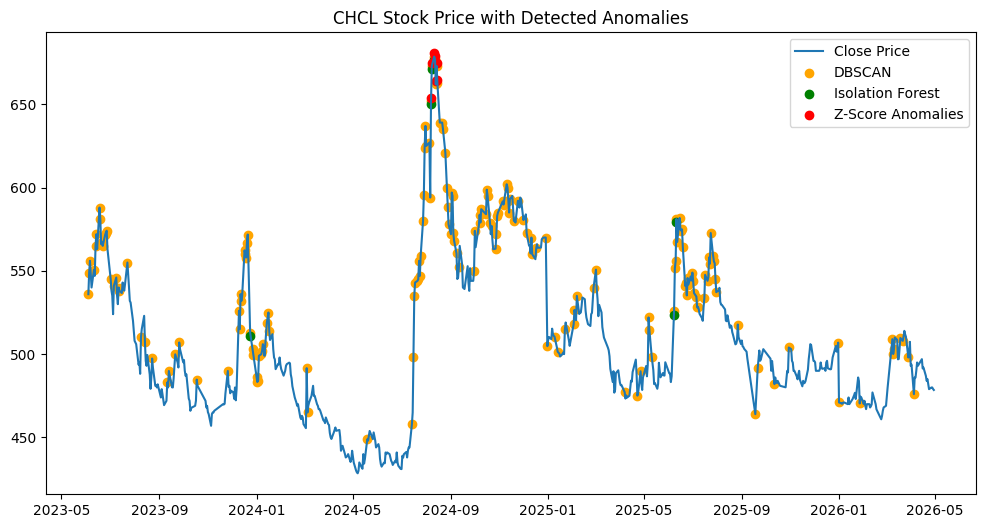

In [33]:
plt.figure(figsize=(12, 6))

plt.plot(df.index, df['rate'], label='Close Price')


plt.scatter(
    df[df['Anomaly_DBSCAN'] == -1].index,
    df[df['Anomaly_DBSCAN'] == -1]['rate'] ,
    color='orange',
    label='DBSCAN'
)

plt.scatter(
    df[df['Anomaly_Isolation_Forest'] == -1].index,
    df[df['Anomaly_Isolation_Forest'] == -1]['rate'] - 2,
    color='green',
    label='Isolation Forest'
)

plt.scatter(
    anomalies_zscore.index,
    anomalies_zscore['rate'] + 2,
    color='red',
    label='Z-Score Anomalies'
)

plt.title(f'{stock_name} Stock Price with Detected Anomalies')
plt.legend()
plt.show()

In [34]:
import plotly.graph_objects as go


fig = go.Figure()

# Add the line for the closing price
fig.add_trace(go.Scatter(
    x=df.index,
    y=df['rate'],
    mode='lines',
    name='Close Price',
    line=dict(color='blue'),
))


# Add the scatter plot for Isolation Forest anomalies
fig.add_trace(go.Scatter(
    x=anomalies_if[anomalies_if['Anomaly_Isolation_Forest'] == -1].index,
    y=anomalies_if[anomalies_if['Anomaly_Isolation_Forest'] == -1]['rate']-2,
    mode='markers',
    name='Isolation Forest Anomalies',
    marker=dict(color='green', size=10),
))

# Add the scatter plot for DBSCAN anomalies
fig.add_trace(go.Scatter(
    x=anomalies_dbscan[anomalies_dbscan['Anomaly_DBSCAN'] == -1].index,
    y=anomalies_dbscan[anomalies_dbscan['Anomaly_DBSCAN'] == -1]['rate'],
    mode='markers',
    name='DBSCAN Anomalies',
    marker=dict(color='orange', size=10),
))

# Add the scatter plot for Z-Score anomalies
fig.add_trace(go.Scatter(
    x=anomalies_zscore.index,
    y=anomalies_zscore['rate']+2,
    mode='markers',
    name='Z-Score Anomalies',
    marker=dict(color='red', size=10),
))


# Update layout
fig.update_layout(
    title=f'{stock_name} Stock Price with Detected Anomalies',
    xaxis_title='Date',
    yaxis_title='Close Price',
    legend_title='Legend',
    width=1200,
    height=600,
)

# Show the plot
fig.show()


In [39]:
print("Number of Z-Score Anomalies:", len(anomalies_zscore))
print("Number of Isolation Forest Anomalies:", len(anomalies_if == -1))
print("Number of DBSCAN Anomalies:", sum(anomalies_dbscan['Anomaly_DBSCAN'] == -1))

Number of Z-Score Anomalies: 7
Number of Isolation Forest Anomalies: 7
Number of DBSCAN Anomalies: 183



Confusion Matrix for Z_Score:
[[639   6]
 [ 15   1]]


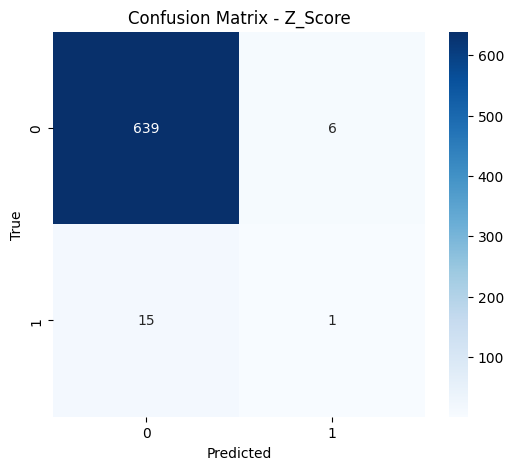


Confusion Matrix for Isolation_Forest:
[[641   4]
 [ 13   3]]


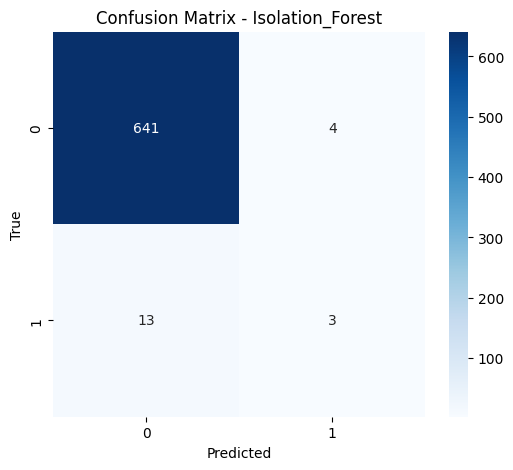


Confusion Matrix for DBSCAN:
[[478 167]
 [  0  16]]


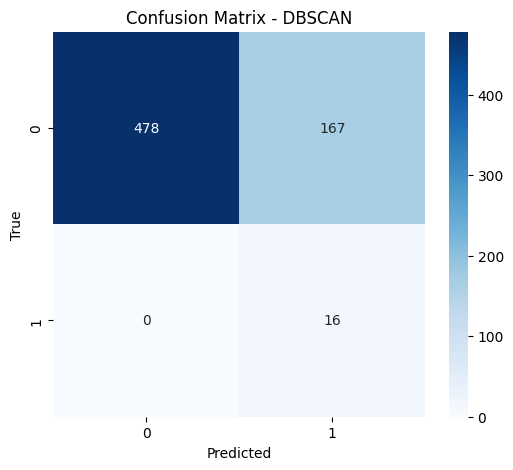


Comparison of all methods:
             Method  Precision  Recall  F1-Score
0           Z_Score   0.142857  0.0625  0.086957
1  Isolation_Forest   0.428571  0.1875  0.260870
2            DBSCAN   0.087432  1.0000  0.160804


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score,confusion_matrix
import seaborn as sns

df['True_Anomaly'] = (df['rate'].pct_change().abs() > 0.05)

methods = ['Z_Score', 'Isolation_Forest', 'DBSCAN']
results = []

for method in methods:
    if method == 'Z_Score':
        predictions = (abs(df['Anomaly_Z_Score']) > 3).astype(int)
    elif method == 'Isolation_Forest':
        predictions = (df['Anomaly_Isolation_Forest'] == -1).astype(int)
    elif method == 'DBSCAN':
        predictions = (df['Anomaly_DBSCAN'] == -1).astype(int)
    
    precision = precision_score(df['True_Anomaly'], predictions)
    recall = recall_score(df['True_Anomaly'], predictions)
    f1 = f1_score(df['True_Anomaly'], predictions)

    cm = confusion_matrix(df["True_Anomaly"], predictions)

    print(f"\nConfusion Matrix for {method}:")
    print(cm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f"Confusion Matrix - {method}")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    plt.show()
    
    results.append({
        'Method': method,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("\nComparison of all methods:")
print(results_df)